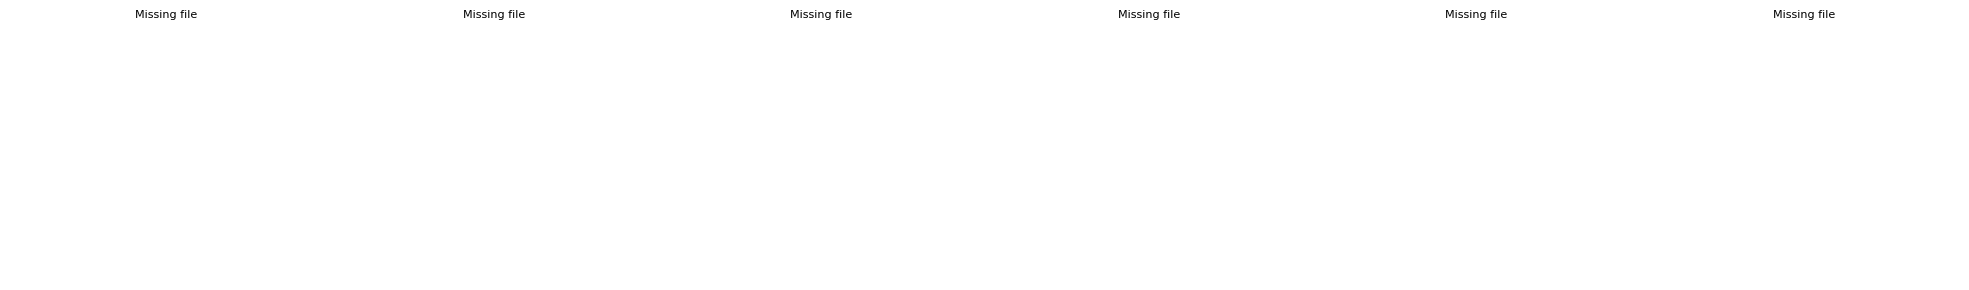

In [4]:
# Plot suspicious/mislabeled TRAIN images from a CSV exported by 09_review_candidates.py
# Works with:
# - candidates_train.csv (model-suspicious)
# - review_manifest_template.csv (if you filled new_label for confirmed relabels)

from pathlib import Path
import csv
import math

import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------
# CONFIG
# ---------------------------

CSV_PATH = Path("review_candidates/review_candidates_20260428_162128/candidates_train.csv")
TOP_N = 6
N_COLS = 6

# If your CSV is a review manifest and you filled new_label, set this True
ONLY_CONFIRMED_RELABELED = False
# ---------------------------


def to_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default


def resolve_img_path(raw_path: str) -> Path:
    p = Path(raw_path)
    if p.is_absolute() and p.exists():
        return p

    candidates = [
        Path.cwd() / p,                 # e.g. project/data/train/...
        Path.cwd().parent / p,          # fallback if run from subdir
    ]
    for c in candidates:
        if c.exists():
            return c
    return Path.cwd() / p  # best effort


rows = []
with CSV_PATH.open("r", encoding="utf-8-sig", newline="") as f:
    reader = csv.DictReader(f)
    for r in reader:
        split = r.get("split", "train").strip().lower()
        if split and split != "train":
            continue

        if ONLY_CONFIRMED_RELABELED:
            # for review manifest file
            new_label = (r.get("new_label") or "").strip().lower()
            if not new_label:
                continue
        else:
            # for candidates_train.csv
            # keep only strong misclassification candidates
            reason = (r.get("candidate_reason") or "").strip().lower()
            is_mis = str(r.get("is_misclassified", "0")).strip() == "1"
            if reason and reason != "misclassified_high_confidence":
                continue
            if not is_mis and reason == "":
                continue

        rows.append(r)

# Sort by suspicion score if available
rows.sort(key=lambda r: to_float(r.get("suspicion_score", 0.0)), reverse=True)
rows = rows[:TOP_N]

if not rows:
    raise RuntimeError("No rows selected. Check CSV_PATH / filters.")

n = len(rows)
n_rows = math.ceil(n / N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(3.3 * N_COLS, 3.0 * n_rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax in axes:
    ax.axis("off")

for i, r in enumerate(rows):
    ax = axes[i]
    img_path = resolve_img_path(r["path"])

    if not img_path.exists():
        ax.set_title("Missing file", fontsize=8)
        continue

    try:
        img = Image.open(img_path).convert("RGB")
    except Exception:
        ax.set_title("Unreadable image", fontsize=8)
        continue

    ax.imshow(img)

    true_label = r.get("true_label", r.get("current_label", "?"))
    pred_label = r.get("pred_label", r.get("model_pred_label", "?"))
    score = to_float(r.get("suspicion_score", 0.0))
    p_pred = to_float(r.get("pred_prob", r.get("model_pred_prob", 0.0)))
    p_true = to_float(r.get("true_prob", r.get("current_label_prob", 0.0)))

    ax.set_title(
        f"T:{true_label}  P:{pred_label}\nscore:{score:.3f}  p_pred:{p_pred:.3f}  p_true:{p_true:.3f}",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


In [5]:
from pathlib import Path
import csv
import math
from typing import Sequence

import matplotlib.pyplot as plt
from PIL import Image


def plot_images_by_csv_index(
    csv_path: str | Path,
    indices: Sequence[int],
    path_col: str = "path",
    cols: int = 4,
    title_cols: tuple[str, ...] = ("split", "true_label", "pred_label", "suspicion_score"),
):
    """
    Plot images by row index from a CSV (0-based index, excluding header).

    Example:
        plot_images_by_csv_index(
            "review_candidates/review_candidates_20260428_162128/candidates_all_splits.csv",
            indices=[0, 1, 2, 10, 25, 40],
        )
    """
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    wanted = sorted(set(int(i) for i in indices if int(i) >= 0))
    if not wanted:
        raise ValueError("No valid indices provided.")

    # Read only needed rows
    selected: list[tuple[int, dict]] = []
    wanted_set = set(wanted)
    max_wanted = max(wanted)

    with csv_path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            if i in wanted_set:
                selected.append((i, row))
            if i > max_wanted and len(selected) == len(wanted_set):
                break

    if not selected:
        raise ValueError("None of the requested indices were found in the CSV.")
    found_idx = {i for i, _ in selected}
    missing = [i for i in wanted if i not in found_idx]
    if missing:
        print(f"Warning: indices not found in CSV: {missing}")

    n = len(selected)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.2 * rows))
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # turn off all first
    for ax in axes:
        ax.axis("off")

    for k, (row_idx, row) in enumerate(selected):
        ax = axes[k]
        raw_path = row.get(path_col, "").strip()
        if not raw_path:
            ax.set_title(f"idx {row_idx+1}: missing '{path_col}'", fontsize=8)
            continue

        p = Path(raw_path)
        if not p.is_absolute():
            p = (Path.cwd() / p).resolve()

        if not p.exists():
            ax.set_title(f"idx {row_idx+1}: file not found", fontsize=8)
            continue

        try:
            img = Image.open(p).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.set_title(f"idx {row_idx+1}: unreadable\n{e}", fontsize=8)
            continue

        meta = [f"idx:{row_idx+1}"]
        for c in title_cols:
            if c in row and row[c] != "":
                meta.append(f"{c}:{row[c]}")
        ax.set_title(" | ".join(meta), fontsize=7)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
CSV_PATH = 'review_candidates/review_candidates_20260429_095522/review_manifest_template.csv'
START_IDX = 0

END_IDX = START_IDX + 100


plot_images_by_csv_index(CSV_PATH, range(START_IDX, END_IDX), path_col='image_ref')

FileNotFoundError: CSV not found: review_candidates/review_candidates_20260429_162128/review_manifest_template.csv